# Documentation du Modèle : Exploration et Ingénierie des Données (EDA)

## 1. Qu'est-ce que ce modèle ?
Ce notebook constitue le "Data Pipeline" (Modèle de préparation des données) du projet TARDIS. Il s'agit de la phase critique d'Extraction, Transformation et Nettoyage (ETL) visant à convertir un jeu de données brut et imparfait en une structure mathématique exploitable par un algorithme d'Intelligence Artificielle.

## 2. Qui le développe et à qui sert-il ?
- Développé par : L'équipe de Data Analysts et Data Engineers.
- Utilisateurs finaux : 
  1. Le modèle de Machine Learning (qui a besoin de données propres).
  2. Les analystes métiers (Business Analysts) de la SNCF cherchant à visualiser les statistiques globales de retard.

## 3. Sur quelles données se base-t-il ?
Il se base sur les données historiques brutes de la SNCF, contenant l'ensemble des trajets, les gares de départ/arrivée, les retards cumulés et les causes de ces retards (météo, infrastructure, etc.).

## 4. Pourquoi ce modèle et pas un autre (Approche et Optimisation) ?
Pour traiter des séries temporelles (dates et retards), nous aurions pu utiliser des modèles de Deep Learning complexes (comme les réseaux de neurones LSTM). Cependant, dans un contexte de gestion ferroviaire, l'interprétabilité est reine. Nous avons choisi une approche par "Feature Engineering" (création manuelle de variables) couplée à un algorithme d'arbres de décision (Random Forest) dans le notebook suivant. Cela garantit un modèle plus rapide à entraîner, moins coûteux en ressources, et dont les décisions sont explicables aux équipes métiers.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("dataset.csv", sep=";")
df.head()
df.head()
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 12070 entries, 0 to 12069
Data columns (total 26 columns):
 #   Column                                                                         Non-Null Count  Dtype
---  ------                                                                         --------------  -----
 0   Date                                                                           12010 non-null  str  
 1   Service                                                                        11830 non-null  str  
 2   Departure station                                                              12011 non-null  str  
 3   Arrival station                                                                12011 non-null  str  
 4   Average journey time                                                           11830 non-null  str  
 5   Number of scheduled trains                                                     11830 non-null  str  
 6   Number of cancelled trains                       

Date                                                                                60
Service                                                                            240
Departure station                                                                   59
Arrival station                                                                     59
Average journey time                                                               240
Number of scheduled trains                                                         240
Number of cancelled trains                                                         239
Cancellation comments                                                            11493
Number of trains delayed at departure                                              240
Average delay of late trains at departure                                          239
Average delay of all trains at departure                                           241
Departure delay comments                   

In [5]:
df.columns

Index(['Date', 'Service', 'Departure station', 'Arrival station',
       'Average journey time', 'Number of scheduled trains',
       'Number of cancelled trains', 'Cancellation comments',
       'Number of trains delayed at departure',
       'Average delay of late trains at departure',
       'Average delay of all trains at departure', 'Departure delay comments',
       'Number of trains delayed at arrival',
       'Average delay of late trains at arrival',
       'Average delay of all trains at arrival', 'Arrival delay comments',
       'Number of trains delayed > 15min',
       'Average delay of trains > 15min (if competing with flights)',
       'Number of trains delayed > 30min', 'Number of trains delayed > 60min',
       'Pct delay due to external causes', 'Pct delay due to infrastructure',
       'Pct delay due to traffic management', 'Pct delay due to rolling stock',
       'Pct delay due to station management and equipment reuse',
       'Pct delay due to passenger handling (

## Nettoyage des Données : Suppression du Bruit (Feature Selection)

**Comment ça fonctionne (Technique) :**
Nous supprimons les colonnes contenant des commentaires textuels libres ("Cancellation comments", etc.).

**Pourquoi c'est comme ça :**
Les algorithmes d'apprentissage automatique standard (comme la Régression Linéaire ou le Random Forest) effectuent des calculs mathématiques et ne peuvent pas traiter directement du texte libre. Conserver ces colonnes nécessiterait des modèles de Traitement du Langage Naturel (NLP) très lourds, ce qui n'est pas pertinent pour prédire des minutes de retard basées sur des statistiques. La suppression de ces colonnes optimise la mémoire et le temps de calcul.

In [6]:
df = df.drop(columns=[
    "Cancellation comments",
    "Departure delay comments",
    "Arrival delay comments"
])

## Intégrité des Données : Valeurs manquantes et Doublons

**Comment ça fonctionne (Technique) :**
1. Remplacement des textes 'nan' par de vraies valeurs nulles (`np.nan`).
2. Suppression des lignes sans date (`dropna`).
3. Suppression des doublons stricts pour un même trajet le même jour (`drop_duplicates`).
4. Typage de la colonne au format `datetime`.

**Pourquoi c'est comme ça :**
La qualité d'un modèle prédictif dépend entièrement de la qualité de ses données ("Garbage In, Garbage Out"). Les doublons créent un biais d'apprentissage en forçant l'algorithme à donner trop de poids à certains trajets. Les valeurs manquantes textuelles font crasher l'entraînement. Ce nettoyage garantit la rigueur mathématique du dataset.

In [7]:
df["Date"] = df["Date"].replace('nan', np.nan)
df = df.dropna(subset=["Date"])
df = df.drop_duplicates(subset=["Date", "Departure station", "Arrival station"])
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

## Formatage Numérique (Data Type Conversion)

**Technique :**
Nous forçons la conversion de toutes les colonnes quantitatives en format numérique. Toute donnée corrompue ou texte parasite dans ces colonnes sera forcé en valeur nulle (`coerce`) puis traité ultérieurement. C'est une étape de standardisation indispensable pour le Machine Learning.

In [8]:
for col in df.columns:
    if col != "Date" and col not in ["Service", "Departure station", "Arrival station"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

## Création de Variables (Feature Engineering)

**Qu'est-ce que c'est :**
L'ingénierie des caractéristiques consiste à extraire de nouvelles informations pertinentes à partir des données existantes.

**Pourquoi c'est comme ça :**
La colonne "Date" brute (ex: 2018-01-01) n'est pas compréhensible par un modèle classique. Nous la décomposons en variables distinctes : l'année, le mois, le jour de la semaine, et un indicateur binaire pour le week-end. 
Cela permet au modèle prédictif de découvrir par lui-même des modèles cachés. Par exemple : "Les retards sont plus fréquents le week-end (is_weekend = 1) ou pendant certains mois d'hiver (month = 12)".

In [9]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["weekday"] = df["Date"].dt.dayofweek
df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x >= 5 else 0)

In [10]:
df.head()

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,...,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",year,month,weekday,is_weekend
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,289.0,11.247809,3.693179,...,36.134454,31.092437,10.924370,15.966387,NaN,0.840336,2018.0,1.0,0.0,0
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,213.0,8.479969,4.567119,...,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,2018.0,1.0,0.0,0
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,21.0,6.239683,0.286283,...,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,2018.0,1.0,0.0,0
3,2018-01-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,71.0,7.235211,0.980000,...,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,2018.0,1.0,0.0,0
4,2018-01-01,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,224.0,6.784673,3.229701,...,15.789474,45.614035,NaN,15.789474,1.754386,1.754386,2018.0,1.0,0.0,0


## Exportation du Modèle de Données

**Où et Quand c'est utilisé :**
Le fruit de tout ce travail de nettoyage est exporté dans un fichier `cleaned_dataset.csv`. Il sera ingéré de manière asynchrone par notre second script `tardis_model.ipynb` pour procéder à l'entraînement mathématique de l'Intelligence Artificielle.

In [11]:
df.to_csv("cleaned_dataset.csv", index=False)

## Analyse Exploratoire et Pertinence Métier (Business Insights)

**À qui ça sert :**
Cette section s'adresse directement au Top Management et aux équipes opérationnelles de la SNCF. Avant même d'avoir recours à l'Intelligence Artificielle, la visualisation des données historiques nettoyées permet de prendre des décisions immédiates.

**Comment ça fonctionne :**
Nous utilisons des agrégations statistiques pour comparer les retards moyens par mois et pour identifier les gares les plus critiques du réseau. Ces indicateurs clés (KPIs) servent de base pour les stratégies d'optimisation de l'entreprise (ex: allouer plus de budget de maintenance à la gare la plus en difficulté).

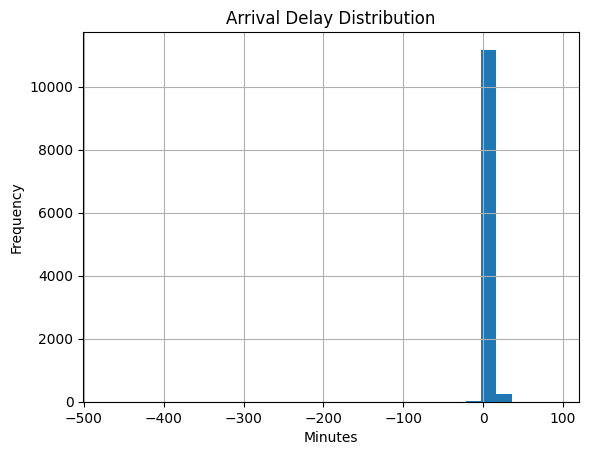

In [12]:
df["Average delay of all trains at arrival"].hist(bins=30)
plt.title("Arrival Delay Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

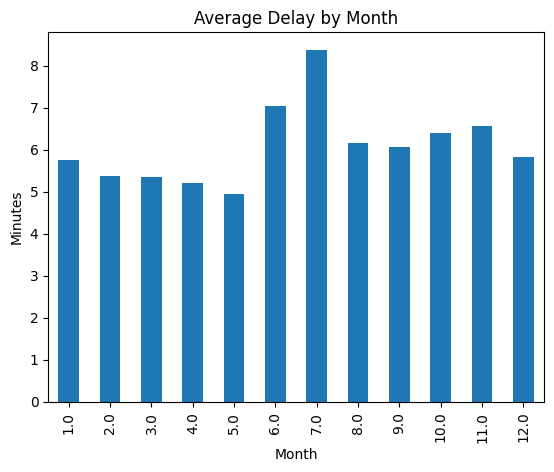

In [13]:
df.groupby("month")["Average delay of all trains at arrival"].mean().plot(kind="bar")
plt.title("Average Delay by Month")
plt.xlabel("Month")
plt.ylabel("Minutes")
plt.show()

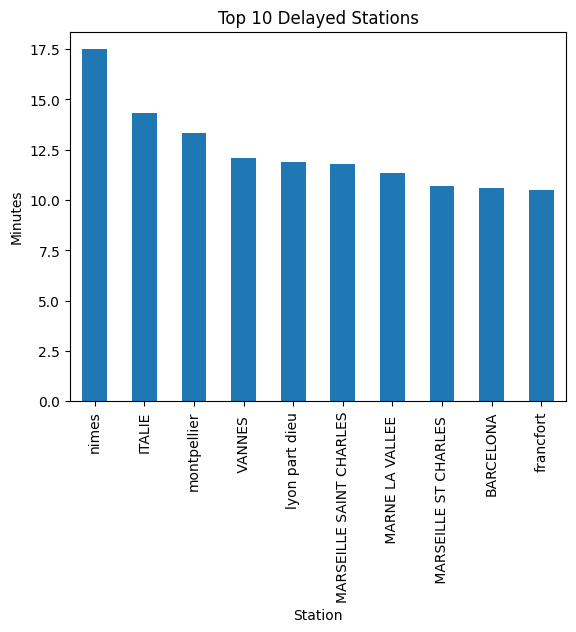

In [14]:
df.groupby("Departure station")["Average delay of all trains at arrival"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Delayed Stations")
plt.xlabel("Station")
plt.ylabel("Minutes")
plt.show()

## Insights

Most delays remain moderate.

Some stations are significantly more impacted.

Delay levels vary depending on the month.